In [3]:
import matplotlib.pyplot as plt
from pprint import pprint
import spikeinterface

import spikeinterface as si  # import core only
import spikeinterface.extractors as se
import spikeinterface.preprocessing as spre
import spikeinterface.sorters as ss
import spikeinterface.postprocessing as spost
import spikeinterface.qualitymetrics as sqm
import spikeinterface.comparison as sc
import spikeinterface.exporters as sexp
import spikeinterface.curation as scur
import spikeinterface.widgets as sw

#and/or
import spikeinterface.full as si

from probeinterface import Probe, get_probe
from probeinterface.plotting import plot_probe

import numpy as np
import pandas as pd
import os

C:\Users\tmerri03\AppData\Local\miniconda3\envs\SpikeSorting\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# set global settings for processing
global_job_kwargs = dict(n_jobs=4, chunk_duration="1s")
si.set_global_job_kwargs(**global_job_kwargs)

Sort 60 trial data using filtered dataset.

In [3]:
oe_path = r"C:\Users\tmerri03\Desktop\Neural Data\60 Trial Data (click no puff)\filtered data"
recording = se.read_openephys(oe_path, stream_id='0')


In [4]:
channel_ids = recording.get_channel_ids()
fs = recording.get_sampling_frequency()
num_chan = recording.get_num_channels()
num_seg = recording.get_num_segments()

print("Channel ids:", channel_ids)
print("Sampling frequency:", fs)
print("Number of channels:", num_chan)
print("Number of segments:", num_seg)

Channel ids: ['CH1' 'CH2' 'CH3' 'CH4' 'CH5' 'CH6' 'CH7' 'CH8' 'CH9' 'CH10' 'CH11'
 'CH12' 'CH13' 'CH14' 'CH15' 'CH16' 'CH17' 'CH18' 'CH19' 'CH20' 'CH21'
 'CH22' 'CH23' 'CH24' 'CH25' 'CH26' 'CH27' 'CH28' 'CH29' 'CH30' 'CH31'
 'CH32']
Sampling frequency: 30000.0
Number of channels: 32
Number of segments: 1


(<matplotlib.collections.PolyCollection at 0x2110a69a6f0>,
 <matplotlib.collections.PolyCollection at 0x2110a6ca8a0>)

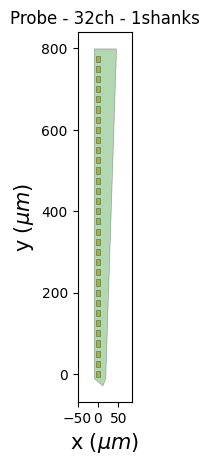

In [5]:
chan_map = [
    29, 19, 18, 28, 30, 20, 17, 21,
    31, 22, 16, 23, 27, 26, 25, 24,
    7, 6, 5, 4, 8, 10, 9, 3,
    11, 2, 12, 1, 13, 0, 14, 15
]
my_probe = get_probe(manufacturer="cambridgeneurotech", probe_name="ASSY-37-H4")
my_probe.set_device_channel_indices(chan_map)
recording_probe = recording.set_probe(my_probe, group_mode='by_shank')
plot_probe(recording_probe.get_probe())

In [6]:
# do not preprocess filtered data

# # recording_cmr = recording_probe
# # recording_f = si.bandpass_filter(recording_probe, freq_min=300, freq_max=10000)
# print(recording_f)
# recording_cmr = si.common_reference(recording_f, reference="global", operator="median")
# print(recording_cmr)
# recording_preprocessed = recording_cmr.save(format="binary")
# print(recording_preprocessed)

In [7]:
print("Available sorters", ss.available_sorters())
print("Installed sorters", ss.installed_sorters())

print("kilosort4 parameters:")
pprint(ss.get_default_sorter_params("kilosort4"))

Available sorters ['combinato', 'hdsort', 'herdingspikes', 'ironclust', 'kilosort', 'kilosort2', 'kilosort2_5', 'kilosort3', 'kilosort4', 'mountainsort4', 'mountainsort5', 'pykilosort', 'rtsort', 'simple', 'spykingcircus', 'spykingcircus2', 'tridesclous', 'tridesclous2', 'waveclus', 'waveclus_snippets', 'yass']
Installed sorters ['kilosort4', 'simple', 'spykingcircus2', 'tridesclous2']
kilosort4 parameters:
{'Th_learned': 8,
 'Th_single_ch': 6,
 'Th_universal': 9,
 'acg_threshold': 0.2,
 'artifact_threshold': inf,
 'bad_channels': None,
 'batch_downsampling': 1,
 'batch_size': 60000,
 'binning_depth': 5,
 'ccg_threshold': 0.25,
 'chunk_duration': '1s',
 'clear_cache': False,
 'cluster_downsampling': 20,
 'cluster_init_seed': 5,
 'cluster_neighbors': 10,
 'delete_recording_dat': True,
 'dmin': None,
 'dminx': 32,
 'do_CAR': True,
 'do_correction': True,
 'drift_smoothing': [0.5, 0.5, 0.5],
 'duplicate_spike_ms': 0.25,
 'highpass_cutoff': 300,
 'invert_sign': False,
 'keep_good_only': Fa

In [8]:
output_folder = r'C:\Users\tmerri03\Desktop\Neural Data\60 Trial Data (click no puff)\filtered data\filtered sorting output'
sorting_TDC = ss.run_sorter(sorter_name="kilosort4", recording=recording_probe, folder=os.path.join(output_folder, 'sorting_TDC')) #add any param changes as arguments to the call
print(sorting_TDC)


100%|██████████| 1/1 [01:38<00:00, 98.72s/it]


KiloSortSortingExtractor: 57 units - 1 segments - 30.0kHz


In [9]:
analyzer_TDC = si.create_sorting_analyzer(sorting=sorting_TDC, recording=recording_probe, format='binary_folder', folder=os.path.join(output_folder, 'analyzer_TDC_binary'))

estimate_sparsity (workers: 4 processes): 100%|██████████| 9314/9314 [00:06<00:00, 1530.46it/s]
C:\Users\tmerri03\AppData\Local\miniconda3\envs\SpikeSorting\Lib\site-packages\spikeinterface\core\basesorting.py:380: UserWarning: The registered recording will not be persistent on disk, but only available in memory
  warnings.warn("The registered recording will not be persistent on disk, but only available in memory")


Sort 60 trial data using unfiltered dataset.


In [10]:
oe_path = r"C:\Users\tmerri03\Desktop\Neural Data\60 Trial Data (click no puff)\unfiltered data"
recording = se.read_openephys(oe_path, stream_id='0')


(<matplotlib.collections.PolyCollection at 0x21151554530>,
 <matplotlib.collections.PolyCollection at 0x21151555af0>)

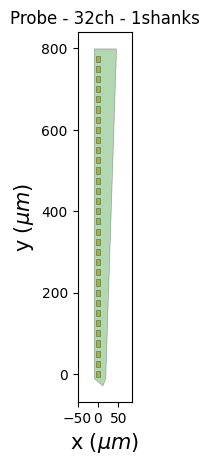

In [11]:
chan_map = [
    29, 19, 18, 28, 30, 20, 17, 21,
    31, 22, 16, 23, 27, 26, 25, 24,
    7, 6, 5, 4, 8, 10, 9, 3,
    11, 2, 12, 1, 13, 0, 14, 15
]
my_probe = get_probe(manufacturer="cambridgeneurotech", probe_name="ASSY-37-H4")
my_probe.set_device_channel_indices(chan_map)
recording_probe = recording.set_probe(my_probe, group_mode='by_shank')
plot_probe(recording_probe.get_probe())

In [12]:
recording_cmr = recording_probe
recording_f = si.bandpass_filter(recording_probe, freq_min=300, freq_max=10000)
print(recording_f)
recording_cmr = si.common_reference(recording_f, reference="global", operator="median")
print(recording_cmr)
recording_preprocessed = recording_cmr.save(format="binary")
print(recording_preprocessed)

BandpassFilterRecording: 32 channels - 30.0kHz - 1 segments - 279,397,500 samples 
                         9,313.25s (2.59 hours) - int16 dtype - 16.65 GiB
CommonReferenceRecording: 32 channels - 30.0kHz - 1 segments - 279,397,500 samples 
                          9,313.25s (2.59 hours) - int16 dtype - 16.65 GiB
Use cache_folder=C:\Users\tmerri03\AppData\Local\Temp\spikeinterface_cache\tmp0p3me_yd\YS1P7VUP
write_binary_recording 
engine=process - n_jobs=4 - samples_per_chunk=30,000 - chunk_memory=1.83 MiB - total_memory=7.32 MiB - chunk_duration=1.00s


write_binary_recording (workers: 4 processes): 100%|██████████| 9314/9314 [01:44<00:00, 88.91it/s]


BinaryFolderRecording: 32 channels - 30.0kHz - 1 segments - 279,397,500 samples 
                       9,313.25s (2.59 hours) - int16 dtype - 16.65 GiB


In [13]:
output_folder = r'C:\Users\tmerri03\Desktop\Neural Data\60 Trial Data (click no puff)\unfiltered data\unfiltered sorting output'
sorting_TDC = ss.run_sorter(sorter_name="kilosort4", recording=recording_preprocessed, folder=os.path.join(output_folder, 'sorting_TDC')) #add any param changes as arguments to the call
print(sorting_TDC)


100%|██████████| 1/1 [01:12<00:00, 72.35s/it]


KiloSortSortingExtractor: 48 units - 1 segments - 30.0kHz


In [14]:
analyzer_TDC = si.create_sorting_analyzer(sorting=sorting_TDC, recording=recording_probe, format='binary_folder', folder=os.path.join(output_folder, 'analyzer_TDC_binary'))

estimate_sparsity (workers: 4 processes): 100%|██████████| 9314/9314 [00:06<00:00, 1509.93it/s]
C:\Users\tmerri03\AppData\Local\miniconda3\envs\SpikeSorting\Lib\site-packages\spikeinterface\core\basesorting.py:380: UserWarning: The registered recording will not be persistent on disk, but only available in memory
  warnings.warn("The registered recording will not be persistent on disk, but only available in memory")


Compare sorting outputs

In [15]:
import numpy as np
import matplotlib.pyplot as plt

import spikeinterface as si
import spikeinterface.extractors as se
import spikeinterface.sorters as ss
import spikeinterface.comparison as sc
import spikeinterface.widgets as sw

In [63]:
unfiltered_sorting_path = r"C:\Users\tmerri03\Desktop\Neural Data\60 Trial Data (click no puff)\unfiltered data\unfiltered sorting output\sorting_TDC"
filtered_sorting_path = r"C:\Users\tmerri03\Desktop\Neural Data\60 Trial Data (click no puff)\filtered data\filtered sorting output\sorting_TDC"

filtered_sorting = si.load(filtered_sorting_path)
unfiltered_sorting = si.load(unfiltered_sorting_path)

cmp_fil_unfil = sc.compare_two_sorters(
    sorting1=filtered_sorting,
    sorting2=unfiltered_sorting,
    sorting1_name='filtered',
    sorting2_name='unfiltered'
)

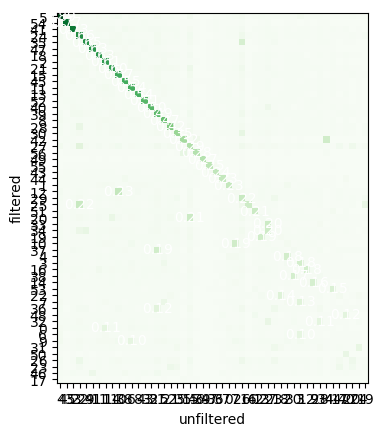

In [64]:
sw.plot_agreement_matrix(cmp_fil_unfil)


In [65]:
print(cmp_fil_unfil.match_event_count)
print(cmp_fil_unfil.agreement_scores)

            0            1           2           3           4           5   \
0   2386.00000  33882.00000  1442.00000  1509.00000  2867.00000  3962.00000   
1  21026.00000   8375.00000  2975.00000   835.00000  1479.00000  2431.00000   
2   1056.00000 169685.00000  1859.00000  1644.00000  3356.00000  7817.00000   
3    662.00000   3394.00000  1482.00000 11686.00000  2376.00000  6642.00000   
4   2130.00000   3538.00000 12330.00000  1267.00000  1097.00000  3253.00000   
5   1090.00000   4765.00000  1123.00000  2431.00000 54070.00000  2189.00000   
6    747.00000   5351.00000   703.00000  5101.00000  2087.00000  1722.00000   
7   1055.00000   5152.00000  1376.00000  8413.00000  1939.00000 10005.00000   
8   1294.00000   9258.00000   561.00000  1538.00000  4223.00000 65135.00000   
9   1253.00000   5467.00000  1786.00000  2659.00000  3133.00000  4217.00000   
10   993.00000   5616.00000  2244.00000   693.00000  1173.00000  2000.00000   
11  2723.00000  10868.00000  1309.00000  1644.00000 

In [66]:
sc_to_tdc, tdc_to_sc = cmp_fil_unfil.get_matching()

print('matching fil to unfil')
print(sc_to_tdc)
print('matching unfil to fil')
print(tdc_to_sc)

matching fil to unfil
0     -1
1     -1
2      1
3     -1
4     -1
5      4
6     -1
7     -1
8     -1
9     -1
10    -1
11     6
12    -1
13     8
14    -1
15    10
16    -1
17    -1
18    11
19    -1
20    -1
21    14
22    -1
23    -1
24    22
25    -1
26    -1
27    -1
28    -1
29    -1
30    -1
31    -1
32    -1
33    -1
34    -1
35    29
36    -1
37    -1
38    -1
39    -1
40    32
41    33
42    -1
43    -1
44    -1
45    38
46    -1
47    41
48    -1
49    -1
50    -1
51    -1
52    43
53    -1
54    45
55    -1
56    -1
dtype: int64
matching unfil to fil
0     -1
1      2
2     -1
3     -1
4      5
5     -1
6     11
7     -1
8     13
9     -1
10    15
11    18
12    -1
13    -1
14    21
15    -1
16    -1
17    -1
18    -1
19    -1
20    -1
21    -1
22    24
23    -1
24    -1
25    -1
26    -1
27    -1
28    -1
29    35
30    -1
31    -1
32    40
33    41
34    -1
35    -1
36    -1
37    -1
38    45
39    -1
40    -1
41    47
42    -1
43    52
44    -1
45    54
46    -1
47    -

In [42]:
print(cmp_fil_unfil.get_best_unit_match1(5))

5


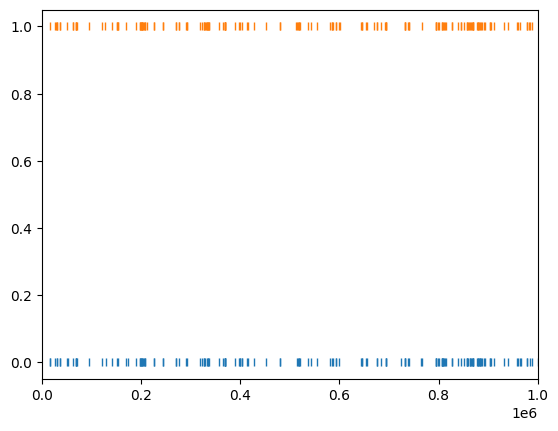

In [31]:
matched_ids = sc_to_tdc[sc_to_tdc != -1]

unit_id_HS = matched_ids.index[1]
unit_id_TDC = matched_ids[unit_id_HS]

# check that matched spike trains correspond
st1 = filtered_sorting.get_unit_spike_train(unit_id_HS)
st2 = unfiltered_sorting.get_unit_spike_train(unit_id_TDC)
fig, ax = plt.subplots()
ax.plot(st1, np.zeros(st1.size), '|')
ax.plot(st2, np.ones(st2.size), '|')
ax.set_xlim(0, 0.01*10**8)

plt.show()

Find Units to Compare by rastering filtered data sorting like before

In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from open_ephys.analysis import Session

In [127]:
oe_path = r"C:\Users\tmerri03\Desktop\Neural Data\60 Trial Data (click no puff)\unfiltered data"


In [128]:
curr_path = oe_path

recordnode_folder = 'Record Node 101'
experiment_folder = 'experiment1'
recording_folder = 'recording3'
curr_path = os.path.join(oe_path, recordnode_folder, experiment_folder, recording_folder)

sync_messages_path = os.path.join(curr_path, 'sync_messages.txt')
print(f'Sync Messages Filepath: {sync_messages_path}')

try:
    with open(sync_messages_path, 'r') as f:
        for line in f:
            line=line.split(" ")
            start_time = int(line[-1])
except FileNotFoundError:
    print(f"Error: start time_path={sync_messages_path} not found at {sync_messages_path}")
except Exception as e:
    print(f"An error occurred while reading start time: {e}")

print(f'\nStart Time: {start_time}')
recording_start_time = start_time

Sync Messages Filepath: C:\Users\tmerri03\Desktop\Neural Data\60 Trial Data (click no puff)\unfiltered data\Record Node 101\experiment1\recording3\sync_messages.txt

Start Time: 136204200


In [129]:
session = Session(oe_path)
recording = session.recordnodes[0].recordings[0]
sample_time = ((recording.events.sample_number) - int(recording_start_time))/30000
sample_time = sample_time[2:]#fix for this recording specifically

In [130]:
diffs = np.diff(sample_time)
mask = (diffs>0.15) & (diffs<6) #filter between 0.15 and 5 seconds
start_time=sample_time[:-1][mask].reset_index(drop=True)
end_time=sample_time[1:][mask].reset_index(drop=True)
durations=diffs[mask]

# ---- and put them all into a dataframe ----
stimuli_arr = pd.DataFrame(columns=['Start Time', 'End Time', 'Duration', 'Stimuli Type'])
stimuli_arr['Start Time'] = start_time
stimuli_arr['End Time'] = end_time
stimuli_arr['Duration'] = durations

In [131]:
stimuli_arr['Start Time'] = stimuli_arr['Start Time'] - 0.5
stimuli_arr['End Time'] = stimuli_arr['End Time'] + 0.5

In [132]:
log_path = r"R:\Data\RhythmPerception\MBL\NCM\07242025\g53o49_NCM_puff(click-noair)_ProbeH4_2025-07-24_14-53-31_site1\Filtered\playback_log_20230412_110019.csv"
log_file = pd.read_csv(log_path)
song_order = log_file['Song']
stimuli_arr['Stimuli Type'] = song_order

In [133]:
stimuli_arr = stimuli_arr[stimuli_arr['Stimuli Type'] == 'Rule_2100reg.wav'].reset_index(drop=True)

In [138]:
spike_times = np.load(r"C:\Users\tmerri03\Desktop\Neural Data\60 Trial Data (click no puff)\unfiltered data\new sorting\new sorting\sorting_TDC\sorter_output\spike_times.npy").astype(int)
spike_clusters = np.load(r"C:\Users\tmerri03\Desktop\Neural Data\60 Trial Data (click no puff)\unfiltered data\new sorting\new sorting\sorting_TDC\sorter_output\spike_clusters.npy").astype(int)

spike_times = (spike_times)/30000

In [147]:
# --- compute quality metrics for each cluster
analyzer_path = r"C:\Users\tmerri03\Desktop\Neural Data\60 Trial Data (click no puff)\unfiltered data\new sorting\new sorting\analyzer_TDC_binary"
analyzer = si.load_sorting_analyzer(analyzer_path)
analyzer.compute("quality_metrics")

if not analyzer.has_extension("spike_amplitudes"):
    analyzer.compute("spike_amplitudes")
if not analyzer.has_extension("spike_locations"):
    analyzer.compute("spike_locations", method="center_of_mass")
if not analyzer.has_extension("templates"):
    analyzer.compute("templates")
if not analyzer.has_extension('isi_histograms'):
    analyzer.compute('isi_histograms')

sqm.compute_quality_metrics(
    analyzer,
    metric_names=[
        "snr",
        "firing_rate",
        "isi_violations",
        "presence_ratio",
    ]
)

qm = analyzer.get_extension("quality_metrics").get_data()

C:\Users\tmerri03\AppData\Local\miniconda3\envs\SpikeSorting\Lib\site-packages\spikeinterface\core\sortinganalyzer.py:2395: UserWarning: Found no run_info file for quality_metrics, extension should be re-computed.
  warnings.warn(f"Found no run_info file for {self.extension_name}, extension should be re-computed.")
C:\Users\tmerri03\AppData\Local\miniconda3\envs\SpikeSorting\Lib\site-packages\spikeinterface\core\sortinganalyzer.py:2478: UserWarning: Found no data for quality_metrics, extension should be re-computed.
  warnings.warn(f"Found no data for {self.extension_name}, extension should be re-computed.")


TypeError: ComputeQualityMetrics._set_params() got an unexpected keyword argument 'unit_ids'

In [123]:

if not analyzer.has_extension("principal_components"):
    analyzer.compute(
        "principal_components",
        n_components=3,
        mode="by_channel_local"
    )

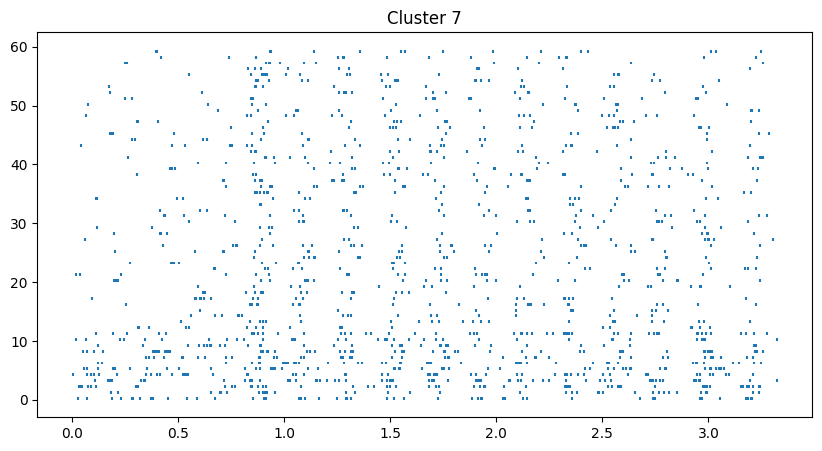

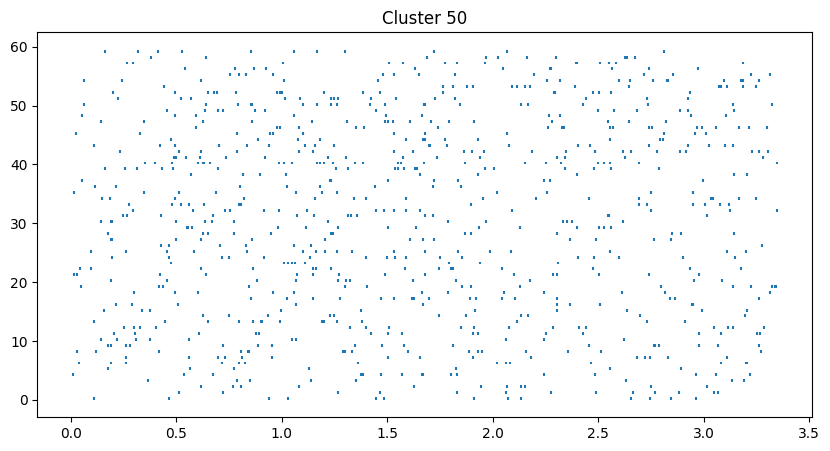

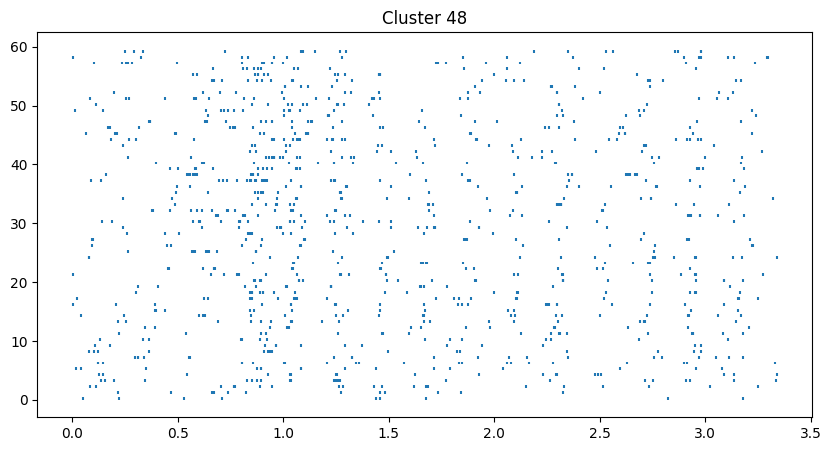

In [125]:
clusters = pd.unique(spike_clusters)
for c, cluster in enumerate(clusters):
    if qm.loc[c, 'snr'] > 3 and qm.loc[c, 'isi_violations_count']/qm.loc[c, 'num_spikes']*100<1:
        spike_times_loc = spike_times[spike_clusters == cluster]

        fig, ax = plt.subplots(figsize=(10,5))
        for r, row in stimuli_arr.iterrows():
            mask = (spike_times_loc > row['Start Time']) & (spike_times_loc < row['End Time'])
            trial_spks = spike_times_loc[mask] - row['Start Time']

            ax.vlines(trial_spks, ymin=r, ymax=r+0.5)
        ax.set_title(f'Cluster {cluster}')
        plt.show()

Compute quality metrics

In [44]:
analyzer_path = r"C:\Users\tmerri03\Desktop\Neural Data\60 Trial Data (click no puff)\unfiltered data\new sorting\new sorting\analyzer_TDC_binary"
analyzer = si.load_sorting_analyzer(analyzer_path)
analyzer.compute("quality_metrics")
qm = analyzer.get_extension("quality_metrics").get_data()

print(qm.columns)




C:\Users\tmerri03\AppData\Local\miniconda3\envs\SpikeSorting\Lib\site-packages\spikeinterface\qualitymetrics\misc_metrics.py:1059: UserWarning: Some units have too few spikes : amplitude_cutoff is set to NaN
  warnings.warn(f"Some units have too few spikes : amplitude_cutoff is set to NaN")
C:\Users\tmerri03\AppData\Local\miniconda3\envs\SpikeSorting\Lib\site-packages\numpy\_core\_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\tmerri03\AppData\Local\miniconda3\envs\SpikeSorting\Lib\site-packages\numpy\_core\_methods.py:180: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
C:\Users\tmerri03\AppData\Local\miniconda3\envs\SpikeSorting\Lib\site-packages\numpy\_core\_methods.py:214: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
noise_level (no parallelization): 100%|██████████| 20/20 [00:00<00:00, 325.52it

Index(['num_spikes', 'firing_rate', 'presence_ratio', 'snr',
       'isi_violations_ratio', 'isi_violations_count', 'rp_contamination',
       'rp_violations', 'sliding_rp_violation', 'amplitude_cutoff',
       'amplitude_median', 'amplitude_cv_median', 'amplitude_cv_range',
       'sync_spike_2', 'sync_spike_4', 'sync_spike_8', 'firing_range',
       'drift_ptp', 'drift_std', 'drift_mad', 'sd_ratio', 'noise_cutoff',
       'noise_ratio'],
      dtype='object')


In [97]:
import pprint
isi_violations = sqm.compute_isi_violations(analyzer, isi_threshold_ms=1.0)
pprint.pprint(len(isi_violations[0]))

48


In [98]:
analyzer.compute(['random_spikes', 'waveforms', 'templates', 'noise_levels'])

noise_level (no parallelization): 100%|██████████| 20/20 [00:00<00:00, 96.29it/s]


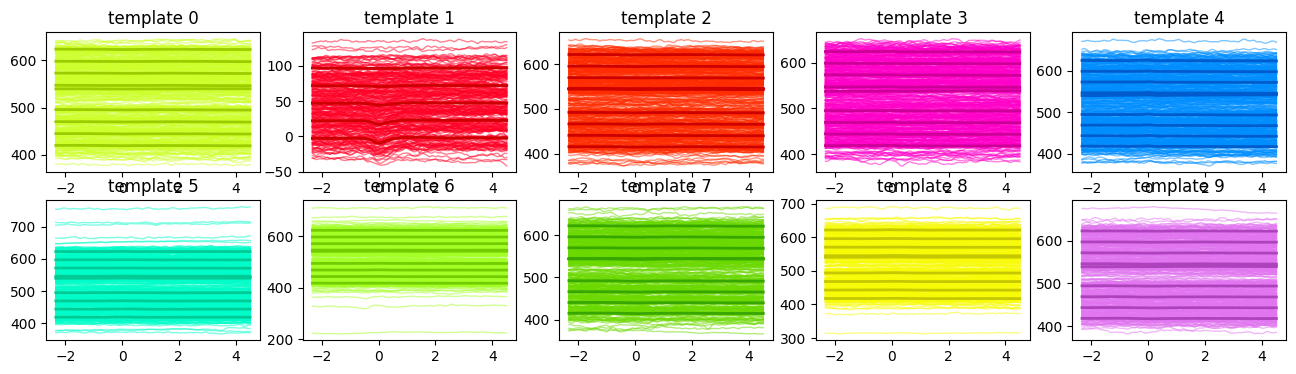

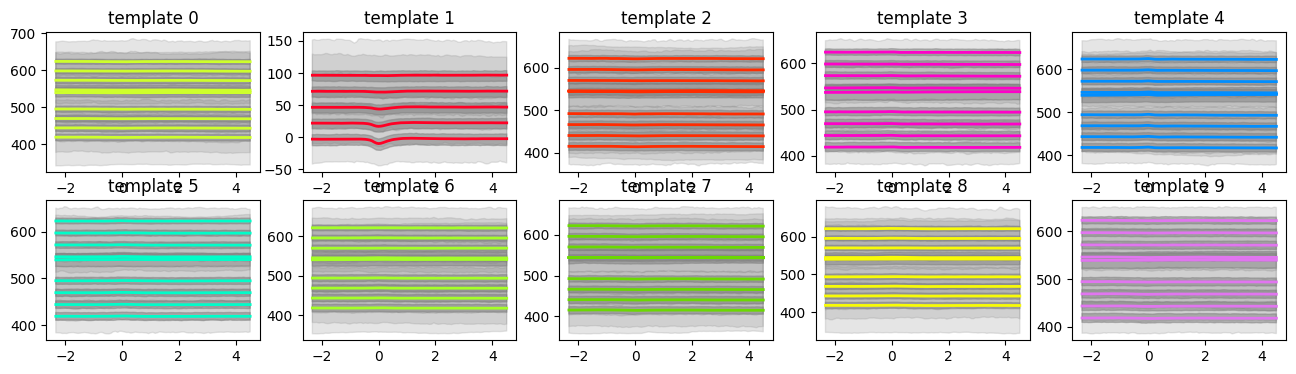

In [115]:
units = unfiltered_sorting.unit_ids
units = units[:10]
sw.plot_unit_waveforms(analyzer, unit_ids=units, figsize=(16,4))
sw.plot_unit_templates(analyzer, unit_ids=units, figsize=(16,4))

In [4]:
sorting = si.load(r"C:\Users\tmerri03\Desktop\Neural Data\60 Trial Data (click no puff)\unfiltered data\unfiltered sorting output\sorting_TDC")
analyzer =si.load_sorting_analyzer(r"C:\Users\tmerri03\Desktop\Neural Data\60 Trial Data (click no puff)\unfiltered data\unfiltered sorting output\analyzer_TDC_binary")

In [6]:
if analyzer.get_extension("random_spikes") is None:
    analyzer.compute("random_spikes")
if analyzer.get_extension("waveforms") is None:
    analyzer.compute("waveforms")
if analyzer.get_extension("noise_levels") is None:
    analyzer.compute("noise_levels")
if analyzer.get_extension("templates") is None:
    analyzer.compute("templates")
if analyzer.get_extension("spike_amplitudes") is None:
    analyzer.compute("spike_amplitudes")

spike_amplitudes (no parallelization): 100%|██████████| 9314/9314 [01:06<00:00, 139.32it/s]


In [7]:
from spikeinterface_gui import run_mainwindow
run_mainwindow(analyzer, mode='desktop', curation=True)

Force compute "unit_locations" is needed


<spikeinterface_gui.backend_qt.QtMainWindow(0x1cc7ea509f0) at 0x000001CC7BA1B200>

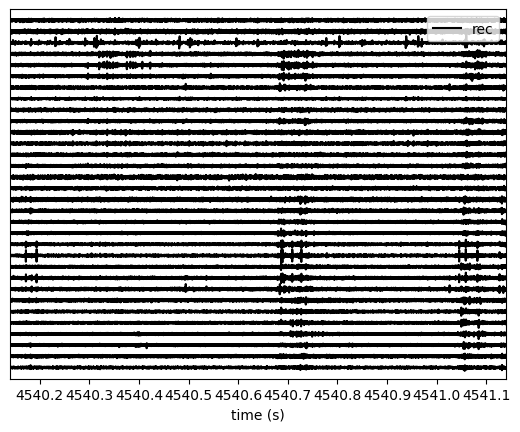

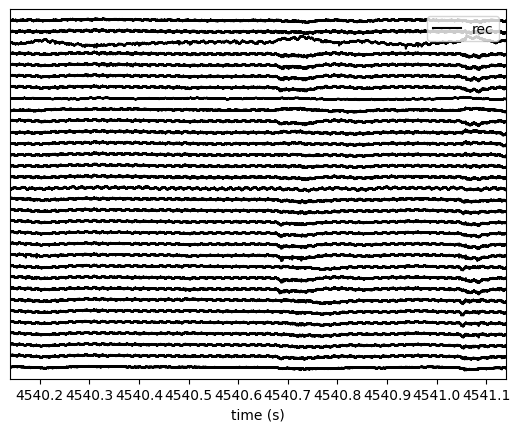

In [11]:
filtered_recording = si.read_openephys(r'C:\Users\tmerri03\Desktop\Neural Data\60 Trial Data (click no puff)\filtered data', stream_id='0')
preprocessed_recording = si.read_openephys(r'C:\Users\tmerri03\Desktop\Neural Data\60 Trial Data (click no puff)\unfiltered data', stream_id='0')

sw.plot_traces(filtered_recording)
sw.plot_traces(preprocessed_recording)

Use cache_folder=C:\Users\tmerri03\AppData\Local\Temp\spikeinterface_cache\tmpia8mev_c\GWOBBDL2
write_binary_recording 
engine=process - n_jobs=1 - samples_per_chunk=30,000 - chunk_memory=1.83 MiB - total_memory=1.83 MiB - chunk_duration=1.00s


write_binary_recording (no parallelization): 100%|██████████| 4920/4920 [01:44<00:00, 46.96it/s]


Use cache_folder=C:\Users\tmerri03\AppData\Local\Temp\spikeinterface_cache\tmpr5kcdkk5\KB1FV0A9
write_binary_recording 
engine=process - n_jobs=1 - samples_per_chunk=30,000 - chunk_memory=1.83 MiB - total_memory=1.83 MiB - chunk_duration=1.00s


write_binary_recording (no parallelization): 100%|██████████| 4920/4920 [02:36<00:00, 31.53it/s] 


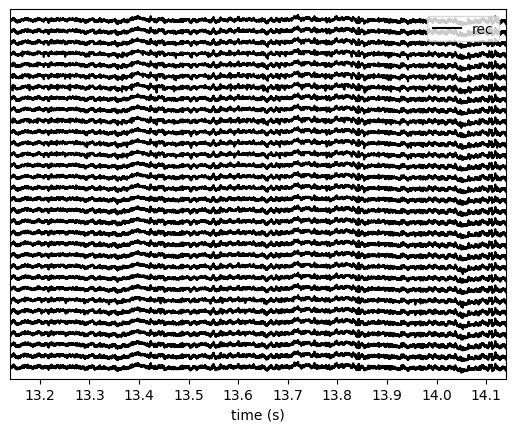

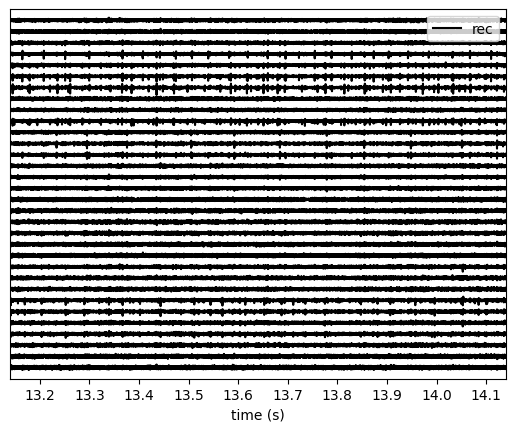

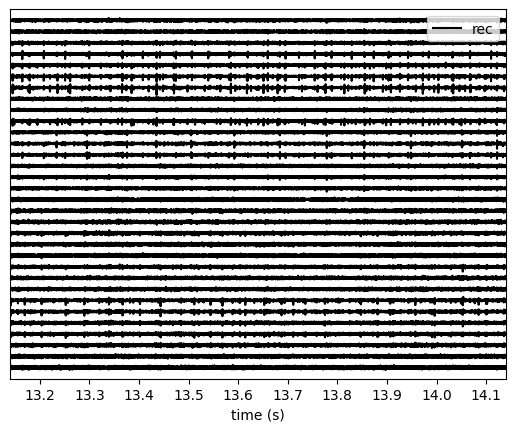

In [16]:
test_recording = si.read_openephys(r'C:\Users\tmerri03\Desktop\Temp Neural Files\w85k85 Recording #3 (P1, HVC, 0AP 2.4ML-R 491um)\unfiltered\w85k85_HVC_2025-12-22_16-05-09_P1_491um', stream_id='0')
sw.plot_traces(test_recording)

recording_cmr = test_recording
recording_f = si.bandpass_filter(test_recording, freq_min=300, freq_max=10000)
recording_cmr = si.common_reference(recording_f, reference="global", operator="average")
recording_preprocessed = recording_cmr.save(format="binary")

sw.plot_traces(recording_preprocessed)

recording_cmr = test_recording
recording_f = si.bandpass_filter(test_recording, freq_min=300, freq_max=10000)
recording_cmr = si.common_reference(recording_f, reference="global", operator="median")
recording_preprocessed = recording_cmr.save(format="binary")

sw.plot_traces(recording_preprocessed)

In [1]:
import sqlite3

# Path to your database
db_path = r"C:\Users\tmerri03\Desktop\Temp Neural Files\neurons.db"  # replace with your DB path

# Connect
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

# Table name
table_name = "neurons"

# Check existing columns
cursor.execute(f"PRAGMA table_info({table_name});")
columns = [col[1] for col in cursor.fetchall()]  # col[1] is the name

# Add column if it doesn't exist
if "spike_width" in columns:
    cursor.execute(f"ALTER TABLE {table_name} DROP COLUMN spike_width;")
    print("Column 'spike_width' removed.")
else:
    print("Column 'spike_width' doesn't exist. Nothing to do.")

if "spike_width_pp" not in columns:
    cursor.execute(f"ALTER TABLE {table_name} ADD COLUMN spike_width_pp REAL;")
    print("Column 'spike_width_pp' added.")
else:
    print("Column 'spike_width_pp' already exists. Nothing to do.")

if "spike_width_hw" not in columns:
    cursor.execute(f"ALTER TABLE {table_name} ADD COLUMN spike_width_hw REAL;")
    print("Column 'spike_width_hw' added.")
else:
    print("Column 'spike_width_hw' already exists. Nothing to do.")

# Commit and close
conn.commit()
conn.close()

Column 'spike_width' removed.
Column 'spike_width_pp' added.
Column 'spike_width_hw' added.
